In [1]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

In [2]:
url = "https://raw.githubusercontent.com/jbrownlee/Datasets/master/pima-indians-diabetes.data.csv"
columns = ["Pregnancies", "Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI", "DiabetesPedigreeFunction", "Age", "Outcome"]
df = pd.read_csv(url, names=columns)
print("Dataset loaded successfully.")
print("Total records:", len(df))
print("\nFirst 5 records:")
print(df.head())

Dataset loaded successfully.
Total records: 768

First 5 records:
   Pregnancies  Glucose  BloodPressure  SkinThickness  Insulin   BMI  \
0            6      148             72             35        0  33.6   
1            1       85             66             29        0  26.6   
2            8      183             64              0        0  23.3   
3            1       89             66             23       94  28.1   
4            0      137             40             35      168  43.1   

   DiabetesPedigreeFunction  Age  Outcome  
0                     0.627   50        1  
1                     0.351   31        0  
2                     0.672   32        1  
3                     0.167   21        0  
4                     2.288   33        1  


In [3]:
X = df.drop("Outcome", axis=1)
y = df["Outcome"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y )

print("Training samples:", len(X_train))
print("Testing samples:", len(X_test))

Training samples: 614
Testing samples: 154


In [4]:
print("Training Logistic Regression (Without Feature Scaling)")
# max_iter increased to prevent non-convergence on unscaled data
model_unscaled = LogisticRegression(max_iter=1000, random_state=42)
model_unscaled.fit(X_train, y_train)

y_pred_unscaled = model_unscaled.predict(X_test)

acc_unscaled = accuracy_score(y_test, y_pred_unscaled)
prec_unscaled = precision_score(y_test, y_pred_unscaled)
rec_unscaled = recall_score(y_test, y_pred_unscaled)
f1_unscaled = f1_score(y_test, y_pred_unscaled)

print("Logistic Regression (Unscaled) completed.")
print(f"Accuracy: {acc_unscaled:.4f}")
print(f"Precision: {prec_unscaled:.4f}")
print(f"Recall: {rec_unscaled:.4f}")
print(f"F1-score: {f1_unscaled:.4f}")

Training Logistic Regression (Without Feature Scaling)
Logistic Regression (Unscaled) completed.
Accuracy: 0.7143
Precision: 0.6087
Recall: 0.5185
F1-score: 0.5600


In [5]:
print("Applying StandardScaler")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
print("Feature scaling completed.")

print("\nTraining Logistic Regression (With Feature Scaling)")
model_scaled = LogisticRegression(random_state=42)
model_scaled.fit(X_train_scaled, y_train)

y_pred_scaled = model_scaled.predict(X_test_scaled)

acc_scaled = accuracy_score(y_test, y_pred_scaled)
prec_scaled = precision_score(y_test, y_pred_scaled)
rec_scaled = recall_score(y_test, y_pred_scaled)
f1_scaled = f1_score(y_test, y_pred_scaled)

print("Logistic Regression (Scaled) completed.")
print(f"Accuracy: {acc_scaled:.4f}")
print(f"Precision: {prec_scaled:.4f}")
print(f"Recall: {rec_scaled:.4f}")
print(f"F1-score: {f1_scaled:.4f}")

Applying StandardScaler
Feature scaling completed.

Training Logistic Regression (With Feature Scaling)
Logistic Regression (Scaled) completed.
Accuracy: 0.7143
Precision: 0.6087
Recall: 0.5185
F1-score: 0.5600


In [9]:
print("Model Comparison")
print("----------------")
print(f"Unscaled -> Accuracy: {acc_unscaled:.4f}, F1-score: {f1_unscaled:.4f}")
print(f"Scaled -> Accuracy: {acc_scaled:.4f}, F1-score: {f1_scaled:.4f}")

if acc_scaled > acc_unscaled:
    print("\nBased on accuracy, the Scaled model performs better.")
elif acc_unscaled > acc_scaled:
    print("\nBased on accuracy, the Unscaled model performs better.")
else:
    print("\nBoth models have the same accuracy.")

Model Comparison
----------------
Unscaled -> Accuracy: 0.7143, F1-score: 0.5600
Scaled -> Accuracy: 0.7143, F1-score: 0.5600

Both models have the same accuracy.


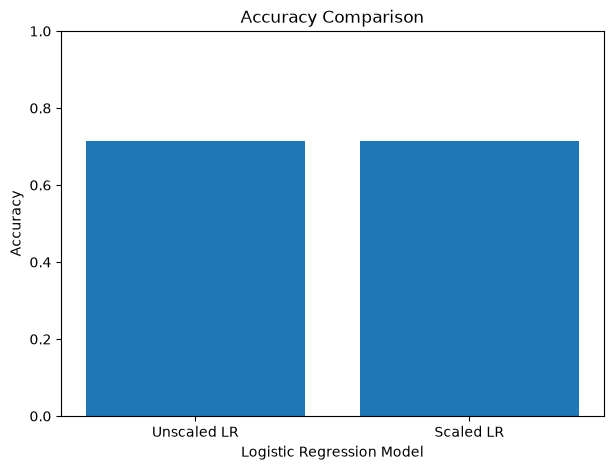

In [10]:
models = ["Unscaled LR", "Scaled LR"]
accuracies = [acc_unscaled, acc_scaled]

plt.figure(figsize=(7, 5))
plt.bar(models, accuracies)
plt.xlabel("Logistic Regression Model")
plt.ylabel("Accuracy")
plt.title("Accuracy Comparison")
plt.ylim(0, 1)
plt.show()

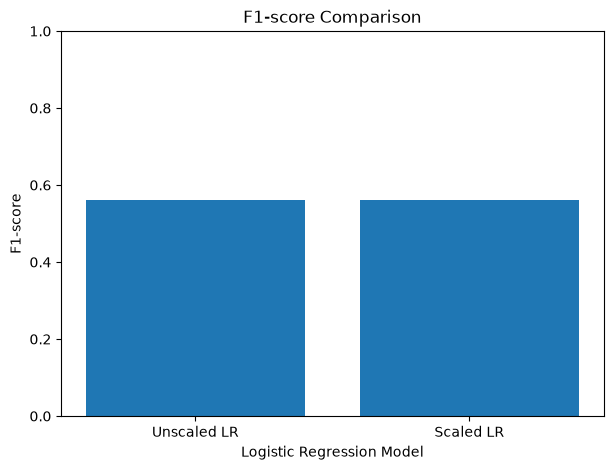

In [11]:
f1_scores = [f1_unscaled, f1_scaled]

plt.figure(figsize=(7, 5))
plt.bar(models, f1_scores)
plt.xlabel("Logistic Regression Model")
plt.ylabel("F1-score")
plt.title("F1-score Comparison")
plt.ylim(0, 1)
plt.show()